## HfstTransducer.view
This restores a version of the view method that is found in the hfst_dev to a curren HFST.

## Setup

In [1]:
import hfst
tr = hfst.regex("[a|b]* c d* [e:f | g:h]+")
tr.view()

AttributeError: 'HfstTransducer' object has no attribute 'view'

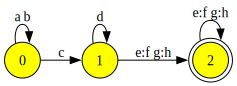

In [2]:
import hfst_transducer_view
hfst_transducer_view.install()
tr.view()

## HFST and Python versions
HFST 3.16.0.1 is current in 06/2026.

In [3]:
hfst.version.version

'3.16.0.1'

In [4]:
import platform
platform.python_version()

'3.12.8'

## Syllable example

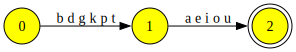

In [5]:
Vow = hfst.regex("[a|e|i|o|u]")
Cons = hfst.regex("[p|b|t|d|k|g]")
CV = Cons.copy()
CV.concatenate(Vow)
CV.minimize()
CV.view()

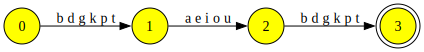

In [6]:
CVC = Cons.copy()
CVC.concatenate(Vow)
CVC.concatenate(Cons)
CVC.minimize()
CVC.view()

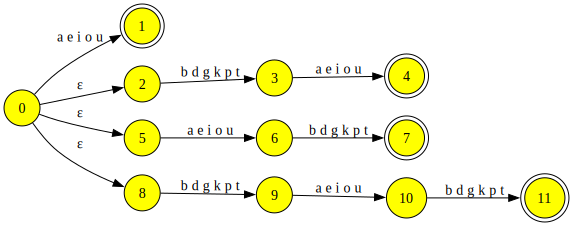

In [7]:
# (C)V(C) syllable
VC = Vow.copy()
VC.concatenate(Cons)
VC.minimize()
Syl = Vow.copy()
Syl.disjunct(CV)
Syl.disjunct(VC)
Syl.disjunct(CVC)
Syl.view()

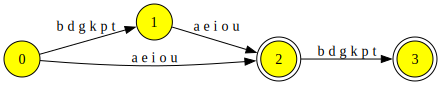

In [8]:
Syl.minimize()
Syl.view()

A word is a sequence of (C)V(C) syllables, with dot separators.

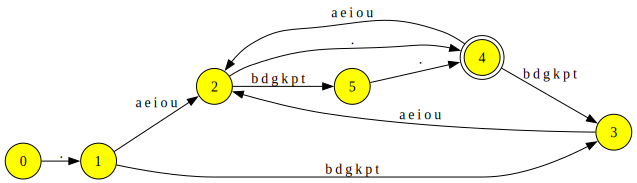

In [9]:
Dot = hfst.regex('"."')
Word = Dot.copy()
Word.concatenate(Syl)
Word.repeat_plus()
Word.concatenate(Dot)
Word.minimize()
Word.view()

## Transducer with devoicing
### Unconstrained devoicing

In [10]:
Devoi = hfst.regex("b -> p, d -> t, g -> k")

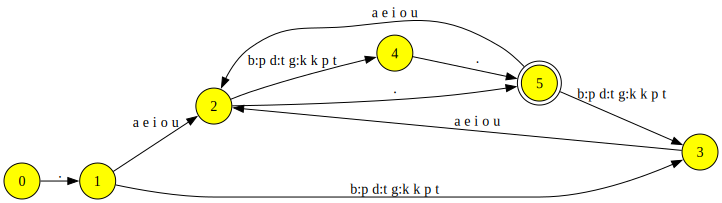

In [11]:
WordRel = Word.copy()
WordRel.compose(Devoi)
WordRel.view()

### Final devoicing

In [12]:
FinalDevoi = hfst.regex('b -> p, d -> t, g -> k || _ "." .#.')

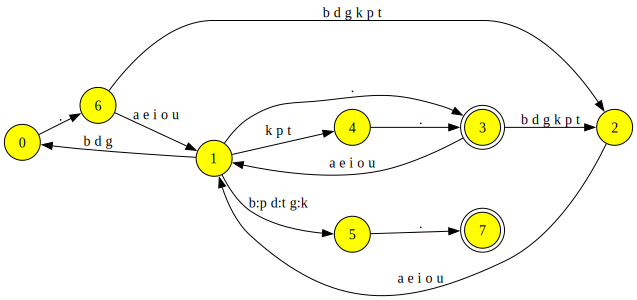

In [13]:
WordRelFinal = Word.copy()
WordRelFinal.compose(FinalDevoi)
WordRelFinal.minimize()
WordRelFinal.view()

## Medial display
Use `display` to show a machine graphically in a non-final position of a code cell.

True


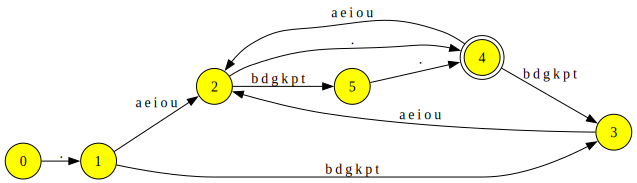

('.',
 '@_EPSILON_SYMBOL_@',
 '@_IDENTITY_SYMBOL_@',
 '@_UNKNOWN_SYMBOL_@',
 'a',
 'b',
 'd',
 'e',
 'g',
 'i',
 'k',
 'o',
 'p',
 't',
 'u')

In [14]:
print(Word.is_automaton())
display(Word.view())
Word.get_alphabet()